# Day 3 - Lab 3: Grouping and association (unsupervised)

**Goal:** leave labels behind. Use k-nearest neighbours as a bridge from supervised thinking, then *discover* structure with clustering and market basket analysis, where there is no correct answer to score against.

The honest theme of this lab: without a label there is no accuracy. You judge unsupervised results with internal measures and business sense, not a test score.

Market basket analysis uses `mlxtend`, pinned in `requirements.txt` and installed with the rest of the environment. This cell only confirms it is present; it does not install anything. If it is missing, run `pip install -r requirements.txt` in your activated `.venv` and restart the kernel.

In [1]:
import importlib.util
if importlib.util.find_spec('mlxtend') is None:
    raise RuntimeError("mlxtend is missing. In your activated .venv run:  "
                       "pip install -r requirements.txt   then restart the kernel.")
import mlxtend
print(f'mlxtend {mlxtend.__version__} ready')

mlxtend 0.23.4 ready


## 1. Load

In [2]:
import pandas as pd, numpy as np
from pathlib import Path

def find_data(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / 'data').is_dir():
            return p / 'data'
    raise FileNotFoundError('data/ folder not found')

DATA = find_data()
df = pd.read_csv(DATA / 'processed' / 'service_requests_features.csv')
honest = ['submitted_hour', 'submitted_dow', 'submitted_month', 'is_weekend',
          'is_digital', 'population', 'priority_rank', 'target_resolution_hours']
print('shape:', df.shape)

shape: (12027, 11)


## 2. k-nearest neighbours: the bridge

kNN is the gentlest possible model: to classify a point, look at its *k* closest neighbours and take a vote. Note carefully, it is still **supervised**, it needs the labels, but it makes decisions purely by distance. That distance idea is exactly what clustering will reuse without labels.

Because kNN works on distance, **scaling matters**: a feature measured in the hundreds of thousands (population) would otherwise drown out everything else.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

lab = df[df['sla_met'].notna()].copy(); lab['sla_met'] = lab['sla_met'].astype(int)
Xtr, Xte, ytr, yte = train_test_split(lab[honest], lab['sla_met'],
                                      test_size=0.25, random_state=42, stratify=lab['sla_met'])
for scale in [False, True]:
    steps = [StandardScaler(), KNeighborsClassifier(n_neighbors=15)] if scale else [KNeighborsClassifier(n_neighbors=15)]
    m = make_pipeline(*steps).fit(Xtr, ytr)
    print(f'kNN {"with" if scale else "without":8s} scaling: accuracy {accuracy_score(yte, m.predict(Xte)):.3f}')

kNN without  scaling: accuracy 0.522
kNN with     scaling: accuracy 0.650


Scaling changes the answer, because it changes what 'nearest' means. Hold that thought: every distance-based method below needs scaled inputs.

## 3. PCA: a 2D window on 8D data

To *see* clusters we need two dimensions, but the data has eight. Principal Component Analysis finds the combinations of features that carry the most variation, so we can plot the top two.

A quiet but important point: a principal component is a weighted sum of features, `w1*x1 + w2*x2 + ...`, which looks identical to a regression equation. But the weights are chosen for the opposite reason. Regression fits weights to a **target** to minimise prediction error. PCA has no target; it chooses weights to **maximise variance** in the data itself. Same formula, entirely different meaning.

In [4]:
from sklearn.decomposition import PCA

Xs = StandardScaler().fit_transform(df[honest].dropna())
pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(Xs)
ev = pca.explained_variance_ratio_
print(f'variance captured: PC1 {ev[0]:.1%}, PC2 {ev[1]:.1%}, together {ev.sum():.1%}')

variance captured: PC1 22.4%, PC2 12.8%, together 35.2%


Two components hold only about a third of the variation, an honest reminder that real tabular data rarely flattens neatly into 2D. The picture is a useful lossy window, not the whole room.

## 4. k-means: find groups without labels

k-means picks *k* centres and shuffles points between them to minimise the spread within each group. There is no right answer, so we judge *k* with the **silhouette** score (how well separated the clusters are, from -1 to 1) and look for an elbow in the inertia.

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X2)
    print(f'k={k}: inertia {km.inertia_:8.0f}   silhouette {silhouette_score(X2, km.labels_):.3f}')

k=2: inertia    14598   silhouette 0.571


k=3: inertia     8984   silhouette 0.469


k=4: inertia     6569   silhouette 0.451


k=5: inertia     5069   silhouette 0.400


In [6]:
# take the best k and describe the groups: print the features that actually differ
best = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X2)
tmp = df[honest].dropna().copy(); tmp['cluster'] = best.labels_
print(tmp.groupby('cluster')[['is_weekend', 'submitted_dow', 'is_digital', 'target_resolution_hours']].mean().round(2))

         is_weekend  submitted_dow  is_digital  target_resolution_hours
cluster                                                                
0               0.0           1.99        0.77                    64.11
1               1.0           5.50        0.77                    64.55


With no labels at all, the clustering split almost perfectly on **whether the request arrived at the weekend** (`is_weekend` 0 versus 1, and the matching day-of-week means), while features like channel and SLA target barely differ between the groups. That is the skill: don't read every column, find the one or two that separate the clusters and name the group by them. Here the unsupervised method rediscovered a real operational divide, weekday versus weekend traffic, which is exactly the kind of structure worth handing to a manager.

### See it: the clusters on the PCA plane

Numbers describe the split; a picture makes it obvious. Here are the same points coloured by their k-means cluster, with the cluster centres marked.

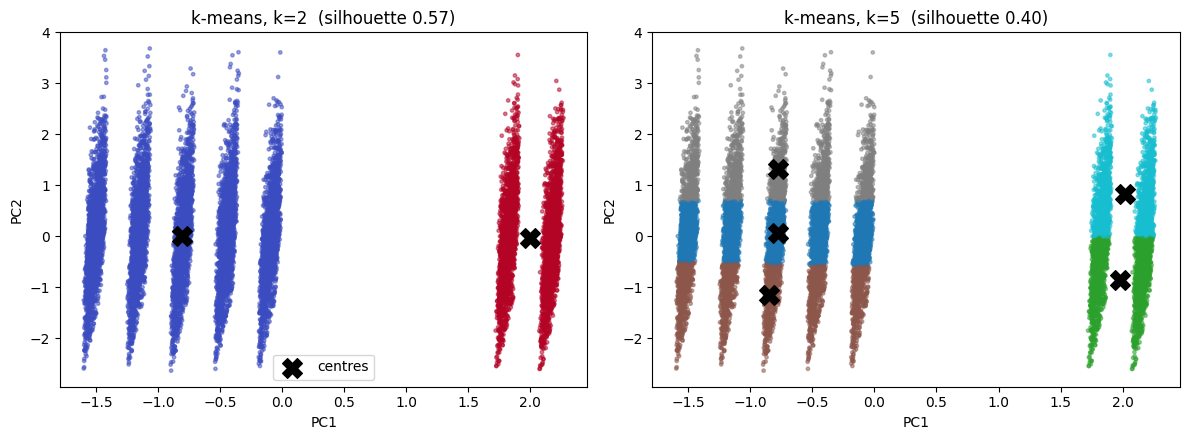

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
km2 = KMeans(n_clusters=2, n_init=10, random_state=42).fit(X2)
axes[0].scatter(X2[:, 0], X2[:, 1], c=km2.labels_, cmap='coolwarm', s=6, alpha=0.5)
axes[0].scatter(km2.cluster_centers_[:, 0], km2.cluster_centers_[:, 1],
                c='black', marker='X', s=200, label='centres')
axes[0].set_title(f'k-means, k=2  (silhouette {silhouette_score(X2, km2.labels_):.2f})')
axes[0].legend()

km5 = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X2)
axes[1].scatter(X2[:, 0], X2[:, 1], c=km5.labels_, cmap='tab10', s=6, alpha=0.5)
axes[1].scatter(km5.cluster_centers_[:, 0], km5.cluster_centers_[:, 1],
                c='black', marker='X', s=200)
axes[1].set_title(f'k-means, k=5  (silhouette {silhouette_score(X2, km5.labels_):.2f})')
for ax in axes:
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
plt.tight_layout(); plt.show()

On the left, two clearly separated bands. On the right, the same space sliced into five, and you can see the algorithm cutting *through* dense regions rather than between them. That is what a lower silhouette score looks like.

### See it: silhouette plots for each k

The single silhouette number is an average, and averages hide things. A silhouette *plot* shows every point's own score, grouped by cluster. Read it like this: wide, long bars reaching well past the dashed average line mean confidently assigned points; bars that are short, or dip below zero, mean points sitting closer to a neighbouring cluster than their own.

A caution worth stating plainly: this is a measure of **separation**, not of generalisation. There is no ground truth here and no test set, so a high silhouette says the groups are tight and distinct, not that they would predict anything on new data.

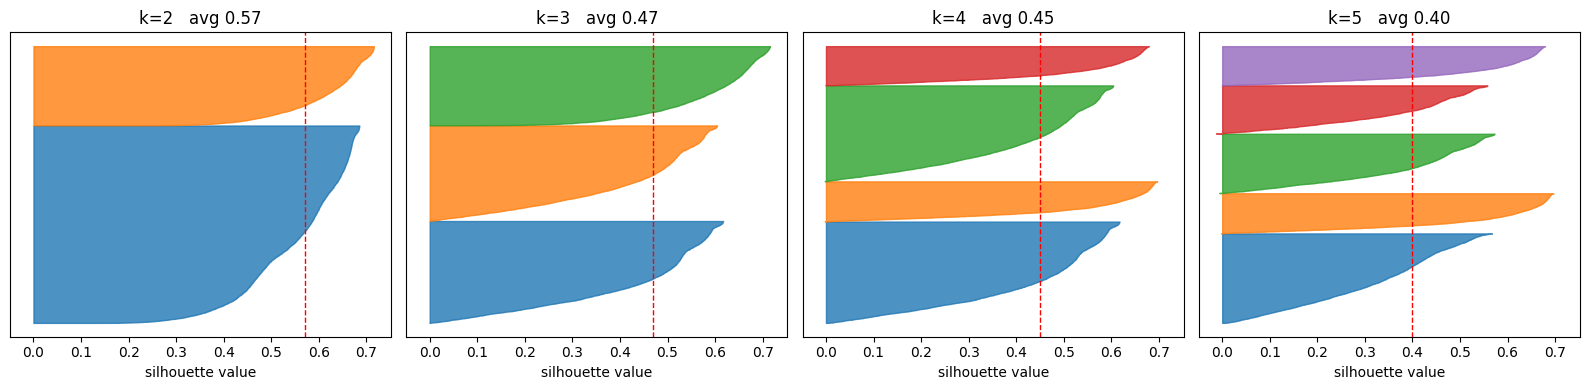

In [8]:
from sklearn.metrics import silhouette_samples

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True)
for ax, k in zip(axes, [2, 3, 4, 5]):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X2)
    vals = silhouette_samples(X2, km.labels_)
    avg = vals.mean()
    y_low = 10
    for i in range(k):
        cv = np.sort(vals[km.labels_ == i])
        y_up = y_low + len(cv)
        ax.fill_betweenx(np.arange(y_low, y_up), 0, cv,
                         color=plt.cm.tab10(i / 10), alpha=0.8)
        y_low = y_up + 10
    ax.axvline(avg, color='red', linestyle='--', linewidth=1)
    ax.set_title(f'k={k}   avg {avg:.2f}')
    ax.set_yticks([]); ax.set_xlabel('silhouette value')
plt.tight_layout(); plt.show()

At k=2 both blocks sit well to the right of the line. As k rises, thin slivers and near-zero bars appear: clusters the algorithm created because you asked for them, not because they were there.

## 5. Agglomerative clustering: a second opinion

Agglomerative (hierarchical) clustering starts with every point alone and repeatedly merges the two nearest groups. It reaches its structure by a completely different route from k-means, so agreement between them is reassuring.

In [9]:
from sklearn.cluster import AgglomerativeClustering

samp = X2[np.random.default_rng(42).choice(len(X2), 2000, replace=False)]
for k in [2, 3, 4]:
    ag = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(samp)
    print(f'k={k}: silhouette {silhouette_score(samp, ag.labels_):.3f}')

k=2: silhouette 0.574
k=3: silhouette 0.456


k=4: silhouette 0.440


Two very different algorithms agreeing that two clusters is cleanest is a stronger signal than either alone.

### See it: the dendrogram

This is the picture k-means cannot give you. A dendrogram draws the entire merge history: every point starts at the bottom, and each horizontal join shows two groups merging, at a height equal to how far apart they were. **Cut the tree at any height and you choose your number of clusters**, which is why hierarchical clustering does not need you to fix k in advance.

Read it for the tall vertical gaps. A long stretch with no joins means the next merge is expensive, so the groups below it are genuinely distinct.

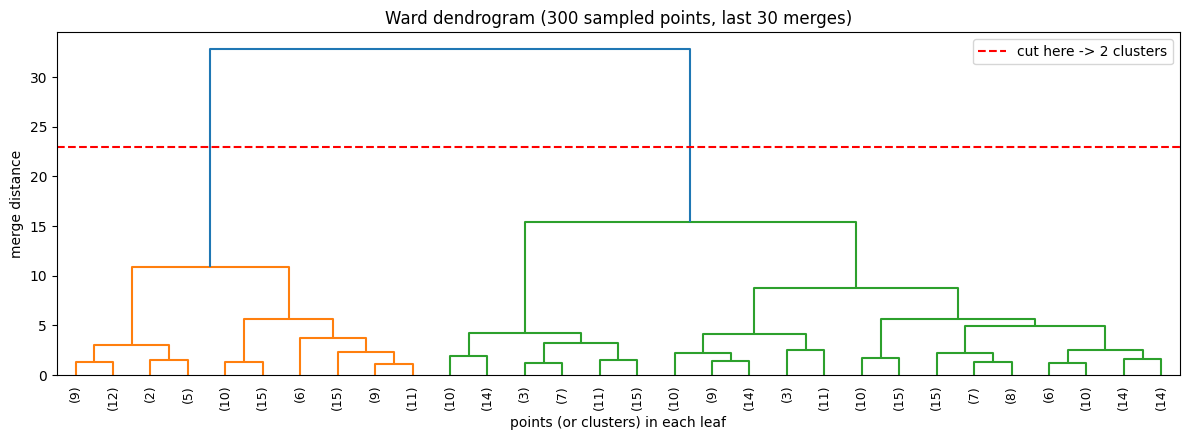

In [10]:
from scipy.cluster.hierarchy import dendrogram, linkage

small = X2[np.random.default_rng(7).choice(len(X2), 300, replace=False)]
Z = linkage(small, method='ward')

plt.figure(figsize=(12, 4.5))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=9,
           color_threshold=Z[-1, 2] * 0.7)
plt.axhline(Z[-1, 2] * 0.7, color='red', linestyle='--',
            label='cut here -> 2 clusters')
plt.title('Ward dendrogram (300 sampled points, last 30 merges)')
plt.ylabel('merge distance'); plt.xlabel('points (or clusters) in each leaf')
plt.legend(); plt.tight_layout(); plt.show()

The tallest unbroken gap sits just below the final merge: cutting there splits the data in two, the same answer k-means reached by a completely different route. Drop the cut lower and you get three, four, five clusters, each less separated than the last.

## 6. Market basket analysis on portal data

Market basket analysis finds items that appear together more than chance would predict. It needs **transactions**, sets of things bought together. Our portal data is not natively transactional (one row per request, no shopper id), so we *construct* a transaction: the set of services requested in the same district on the same day.

Watch the strength of the rules, measured by **lift** (how many times more often two services co-occur than if they were independent). This is the honest part of the exercise.

In [11]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

clean = pd.read_csv(DATA / 'processed' / 'service_requests_clean.csv', parse_dates=['submitted_at'])
svc = pd.read_csv(DATA / 'seeds' / 'services.csv')
clean = clean.merge(svc[['service_id', 'service_name']], on='service_id', how='left')
clean['date'] = clean['submitted_at'].dt.date

baskets = clean.groupby(['district_id', 'date'])['service_name'].apply(lambda s: sorted(set(s)))
baskets = baskets[baskets.apply(len) >= 2]
print(f'constructed transactions: {len(baskets):,}   average basket size: {baskets.apply(len).mean():.1f}')

te = TransactionEncoder()
enc = pd.DataFrame(te.fit_transform(baskets.tolist()), columns=te.columns_)
freq = apriori(enc, min_support=0.05, use_colnames=True)
rules = association_rules(freq, metric='lift', min_threshold=1.0).sort_values('lift', ascending=False)
print(f'rules found: {len(rules)}   highest lift: {rules["lift"].max():.3f}')

constructed transactions: 2,393   average basket size: 3.9
rules found: 158   highest lift: 1.094


The strongest rule barely clears a lift of 1.1, which is little better than random co-occurrence. That is the real lesson, not a failure of the code: municipal service requests in a district do not genuinely 'go together' the way groceries do. When you force a transaction grain onto non-transactional data, weak rules are the honest result. Your homework runs the same technique on data that *is* natively transactional, and the difference will be stark.

## 7. What 'good' means without a label

Notice there was never a test-set accuracy in this lab. Clustering is judged by separation and by whether the groups mean something to the business; association rules by support, confidence and lift, and by whether a rule is *actionable*. Discovery is judged differently from prediction, and pretending otherwise is how unsupervised work goes wrong.

## Your turn

1. Re-run the k-means groups on the **full** 8 scaled features instead of the 2 PCA components. Does the best silhouette still point to two clusters?
2. Raise the market basket `min_support` and lower it. How does the number of rules respond, and what does a very low support threshold risk?
3. In one sentence, state a business question that clustering (not classification) is the right tool for here.

In [12]:
# your turn
